# Thực hành Matplotlib từ cơ bản đến ứng dụng

**Ngôn ngữ:** Python 3  
**Thời lượng gợi ý:** 120–150 phút  
**Dữ liệu:** tự sinh, mô phỏng bán hàng – marketing – vận hành  
**Phiên bản:** 24/08/2026

Notebook này đi cùng bài giảng Matplotlib và ưu tiên cách viết **hướng đối tượng** (`fig, ax = plt.subplots()`). Mỗi phần gồm:

1. Lệnh cốt lõi;
2. Ví dụ đã chạy và có kết quả;
3. Nhận xét cần đọc biểu đồ;
4. Bài tập nhỏ có gợi ý;
5. Bài thực hành tổng hợp ở cuối.

> Cách học hiệu quả: chạy notebook từ trên xuống; sau đó quay lại các ô có nhãn `TODO`, sửa mã và chạy lại.


## Mục tiêu học tập

Sau bài thực hành, người học có thể:

- phân biệt `Figure`, `Axes` và các thành phần của biểu đồ;
- tạo line chart, bar chart, scatter plot, histogram, box plot và pie chart;
- đặt tiêu đề, nhãn trục, legend, grid, marker, màu và độ trong suốt;
- dùng annotation, subplot, colormap, heatmap, contour và đồ thị 3D;
- kết hợp Matplotlib với Pandas và Seaborn;
- đóng gói mã vẽ thành hàm tái sử dụng;
- xuất biểu đồ sang PNG, PDF và SVG.

### Quy ước trình bày

- **Dữ liệu trước, hình sau:** luôn kiểm tra biến và đơn vị đo trước khi vẽ.
- **Một thông điệp chính:** tiêu đề nên nói rõ câu hỏi hoặc kết luận.
- **Axes-first:** ưu tiên `ax.plot(...)`, `ax.set_title(...)` thay vì phụ thuộc hoàn toàn vào `plt.*`.


## 0. Chuẩn bị môi trường

Nếu máy chưa có thư viện, chạy ngoài notebook:

```bash
pip install matplotlib numpy pandas seaborn
```

Trong notebook này, `numpy` dùng để tạo dữ liệu, `pandas` dùng để tổ chức bảng, còn `seaborn` chỉ dùng ở một phần mở rộng.


In [1]:
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Thiết lập chung: dùng font hỗ trợ tiếng Việt, tăng độ phân giải hình.
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 180,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

print("Python:", sys.version.split()[0])
print("Matplotlib:", matplotlib.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


Python: 3.12.13
Matplotlib: 3.10.8
NumPy: 2.3.5
Pandas: 2.2.3


## 1. Tạo bộ dữ liệu kinh doanh mẫu

Ta dùng seed cố định để mọi người nhận được cùng một kết quả. Bộ dữ liệu gồm:

- doanh thu, chi phí, số đơn theo tháng;
- doanh số theo khu vực;
- chi phí quảng cáo và doanh số theo chiến dịch;
- thời gian giao hàng và giá trị đơn hàng.


In [2]:
rng = np.random.default_rng(42)

months = pd.date_range("2025-01-01", periods=12, freq="MS")
trend = np.linspace(0, 360, 12)
season = 230 * np.sin(np.linspace(0, 2 * np.pi, 12, endpoint=False))

revenue = 2350 + trend + season + rng.normal(0, 95, 12)
cost = 1500 + 0.52 * trend + 100 * np.sin(np.linspace(0, 2 * np.pi, 12, endpoint=False) + 0.7) + rng.normal(0, 65, 12)
orders = np.round(revenue / rng.normal(2.55, 0.08, 12)).astype(int)

monthly = pd.DataFrame({
    "Tháng": months,
    "Doanh thu": revenue.round(0),
    "Chi phí": cost.round(0),
    "Số đơn": orders,
})
monthly["Lợi nhuận"] = monthly["Doanh thu"] - monthly["Chi phí"]

regions = pd.DataFrame({
    "Khu vực": ["Miền Bắc", "Miền Trung", "Miền Nam", "Tây Nguyên", "ĐBSCL"],
    "Doanh số": [3280, 1840, 4210, 1260, 2380],
    "Tăng trưởng (%)": [8.4, 5.1, 12.7, -2.8, 6.6],
})

n_campaigns = 70
ad_spend = rng.uniform(20, 180, n_campaigns)
campaign_type = rng.choice(["Tìm kiếm", "Mạng xã hội", "Video"], n_campaigns, p=[0.38, 0.40, 0.22])
type_effect = np.select(
    [campaign_type == "Tìm kiếm", campaign_type == "Mạng xã hội", campaign_type == "Video"],
    [65, 30, 5],
)
sales = 260 + 4.3 * ad_spend + type_effect + rng.normal(0, 95, n_campaigns)
campaigns = pd.DataFrame({
    "Chi quảng cáo": ad_spend,
    "Doanh số": sales,
    "Kênh": campaign_type,
    "Số khách": rng.integers(40, 600, n_campaigns),
})

delivery = pd.DataFrame({
    "Thời gian giao (giờ)": np.clip(rng.gamma(shape=3.6, scale=8.0, size=320), 4, 92),
    "Giá trị đơn": np.clip(rng.lognormal(mean=5.15, sigma=0.55, size=320), 40, 850),
    "Đúng hạn": rng.choice(["Có", "Không"], 320, p=[0.84, 0.16]),
})

print("Bảng theo tháng:")
print(monthly.head().to_string(index=False))
print("\nKích thước các bảng:", monthly.shape, regions.shape, campaigns.shape, delivery.shape)


Bảng theo tháng:
     Tháng  Doanh thu  Chi phí  Số đơn  Lợi nhuận
2025-01-01     2379.0   1569.0     946      810.0
2025-02-01     2399.0   1684.0     951      715.0
2025-03-01     2686.0   1663.0    1036     1023.0
2025-04-01     2768.0   1572.0    1073     1196.0
2025-05-01     2495.0   1626.0     966      869.0

Kích thước các bảng: (12, 5) (5, 3) (70, 4) (320, 3)


### Kiểm tra dữ liệu trước khi vẽ

Ba câu hỏi nên trả lời trước:

1. Mỗi hàng đại diện cho đối tượng nào?
2. Biến nào là phân loại, biến nào là số, biến nào là thời gian?
3. Đơn vị của mỗi trục sẽ là gì?


In [3]:
print("Kiểu dữ liệu:\n", monthly.dtypes)
print("\nThống kê thời gian giao hàng:\n", delivery["Thời gian giao (giờ)"].describe().round(2))
print("\nGiá trị thiếu:", int(monthly.isna().sum().sum() + campaigns.isna().sum().sum()))


Kiểu dữ liệu:
 Tháng        datetime64[ns]
Doanh thu           float64
Chi phí             float64
Số đơn                int64
Lợi nhuận           float64
dtype: object

Thống kê thời gian giao hàng:
 count    320.00
mean      28.29
std       14.86
min        4.00
25%       17.16
50%       26.26
75%       36.04
max       92.00
Name: Thời gian giao (giờ), dtype: float64

Giá trị thiếu: 0


## 2. Figure và Axes: mô hình cốt lõi

- `Figure`: toàn bộ khung hình, có thể chứa nhiều biểu đồ.
- `Axes`: vùng vẽ thực tế, có hệ trục, tiêu đề, nhãn, dữ liệu.
- `Artist`: mọi thành phần được vẽ như đường, chữ, legend, marker.

Mẫu lệnh quan trọng nhất:

```python
fig, ax = plt.subplots()
ax.plot(x, y)
```


Kiểu của fig: Figure
Kiểu của ax: Axes
Kiểu của đường: Line2D


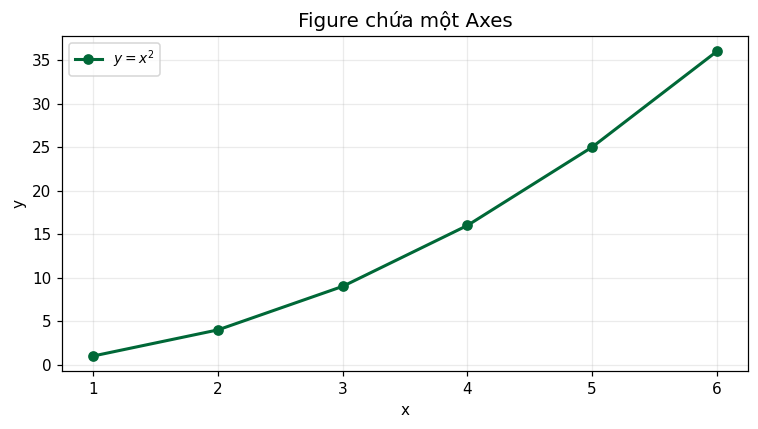

In [4]:
x = np.arange(1, 7)
y = x ** 2

fig, ax = plt.subplots(figsize=(7, 4))
line, = ax.plot(x, y, marker="o", linewidth=2, color="#006837", label=r"$y=x^2$")
ax.set(title="Figure chứa một Axes", xlabel="x", ylabel="y")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()

print("Kiểu của fig:", type(fig).__name__)
print("Kiểu của ax:", type(ax).__name__)
print("Kiểu của đường:", type(line).__name__)


### Bài tập 1 — Làm quen với Axes

Sửa ô dưới đây để:

- vẽ `y = x³`;
- dùng marker hình vuông (`"s"`);
- đặt tiêu đề `Hàm bậc ba`;
- bật lưới với `alpha=0.2`.

**Gợi ý:** thay `# TODO` bằng các lệnh `ax.plot`, `ax.set` và `ax.grid`.


In [5]:
# TODO: bỏ dấu # và hoàn thiện các dòng bên dưới.
x_bt1 = np.arange(-4, 5)
y_bt1 = x_bt1 ** 3

# fig, ax = plt.subplots(figsize=(7, 4))
# ax.plot(...)
# ax.set(...)
# ax.grid(...)
# fig.tight_layout()

print("Bài tập 1 đã sẵn sàng. Hãy bỏ dấu # và hoàn thiện mã.")


Bài tập 1 đã sẵn sàng. Hãy bỏ dấu # và hoàn thiện mã.


## 3. Line chart — xu hướng theo thời gian

Line chart phù hợp khi trục hoành có thứ tự tự nhiên, đặc biệt là thời gian. Không nên nối các danh mục không có thứ tự vì đường nối có thể tạo cảm giác liên tục giả.

Các tham số thường dùng:

- `color`, `linewidth`, `linestyle`;
- `marker`, `markersize`;
- `label` để tạo legend;
- `alpha` để điều chỉnh độ trong suốt.


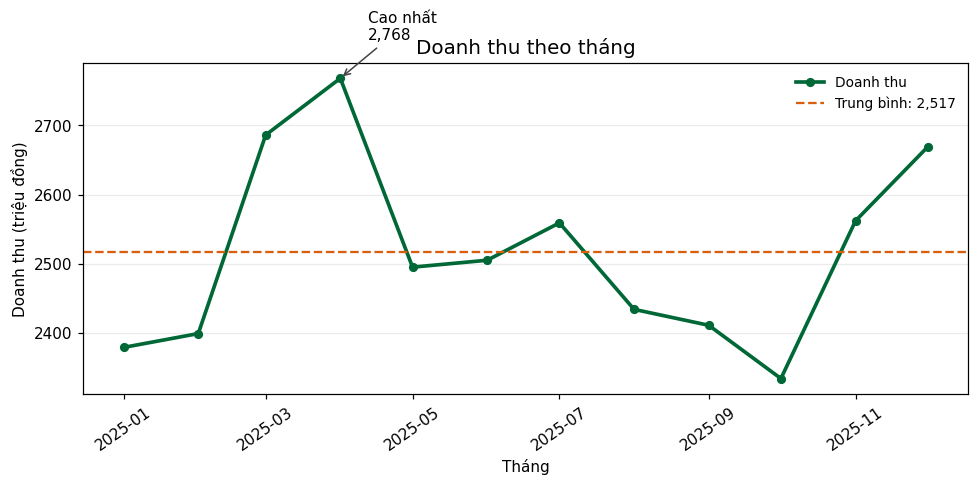

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    monthly["Tháng"], monthly["Doanh thu"],
    color="#006837", linewidth=2.4, marker="o", markersize=5,
    label="Doanh thu",
)

avg_revenue = monthly["Doanh thu"].mean()
ax.axhline(avg_revenue, color="#d95f0e", linestyle="--", linewidth=1.5,
           label=f"Trung bình: {avg_revenue:,.0f}")

peak_idx = monthly["Doanh thu"].idxmax()
peak = monthly.loc[peak_idx]
ax.annotate(
    f"Cao nhất\n{peak['Doanh thu']:,.0f}",
    xy=(peak["Tháng"], peak["Doanh thu"]),
    xytext=(18, 25), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#444444"},
)

ax.set(title="Doanh thu theo tháng", xlabel="Tháng", ylabel="Doanh thu (triệu đồng)")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()


### Nhiều đường trên cùng một Axes

Chỉ nên đặt nhiều đường chung một trục tung khi chúng có cùng hoặc tương thích về đơn vị. Ở đây doanh thu và chi phí đều dùng triệu đồng.


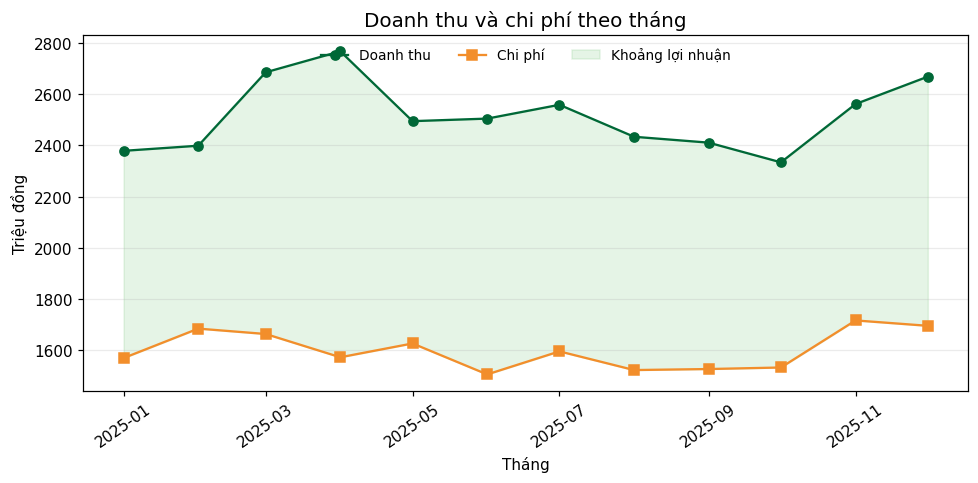

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(monthly["Tháng"], monthly["Doanh thu"], marker="o", color="#006837", label="Doanh thu")
ax.plot(monthly["Tháng"], monthly["Chi phí"], marker="s", color="#f28e2b", label="Chi phí")
ax.fill_between(
    monthly["Tháng"], monthly["Chi phí"], monthly["Doanh thu"],
    where=monthly["Doanh thu"] >= monthly["Chi phí"],
    color="#74c476", alpha=0.18, label="Khoảng lợi nhuận",
)
ax.set(title="Doanh thu và chi phí theo tháng", ylabel="Triệu đồng", xlabel="Tháng")
ax.grid(axis="y", alpha=0.25)
ax.legend(ncols=3, frameon=False, loc="upper center")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()


### Bài tập 2 — Line chart

Vẽ **lợi nhuận theo tháng**. Thêm đường ngang tại 0 và tô đỏ những điểm có lợi nhuận âm (nếu có).

**Gợi ý:** dùng `ax.plot`, `ax.axhline`; tạo mặt nạ Boolean `monthly["Lợi nhuận"] < 0` rồi dùng `ax.scatter`.


In [8]:
# TODO — mã khung không tạo lỗi khi chạy toàn bộ notebook.
loss_mask = monthly["Lợi nhuận"] < 0

# fig, ax = plt.subplots(figsize=(9, 4))
# ax.plot(monthly["Tháng"], monthly["Lợi nhuận"], ...)
# ax.axhline(0, ...)
# ax.scatter(monthly.loc[loss_mask, "Tháng"], monthly.loc[loss_mask, "Lợi nhuận"], ...)

print("Số tháng lợi nhuận âm trong dữ liệu mẫu:", int(loss_mask.sum()))


Số tháng lợi nhuận âm trong dữ liệu mẫu: 0


## 4. Bar chart — so sánh giữa các nhóm

Bar chart phù hợp với biến phân loại. Các nguyên tắc chính:

- trục giá trị thường nên bắt đầu từ 0;
- sắp xếp giúp người đọc nhận ra thứ hạng;
- bar ngang hữu ích khi nhãn danh mục dài;
- có thể dùng `ax.bar_label(...)` để ghi giá trị.


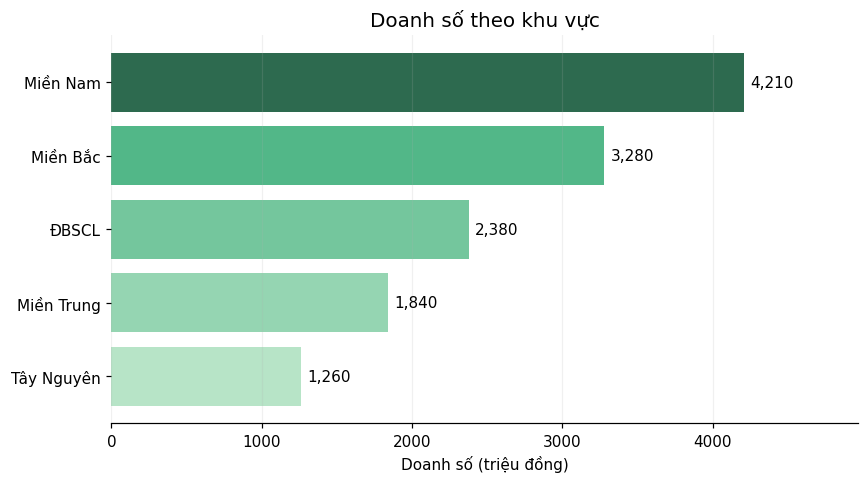

In [9]:
regions_sorted = regions.sort_values("Doanh số")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(
    regions_sorted["Khu vực"], regions_sorted["Doanh số"],
    color=["#b7e4c7", "#95d5b2", "#74c69d", "#52b788", "#2d6a4f"],
)
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in regions_sorted["Doanh số"]], padding=4)
ax.set(title="Doanh số theo khu vực", xlabel="Doanh số (triệu đồng)", ylabel="")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.18)
ax.set_xlim(0, regions_sorted["Doanh số"].max() * 1.18)
fig.tight_layout()


### Bar chart với giá trị dương và âm

Màu có thể mã hóa dấu của tăng trưởng. Đường tại 0 giúp người đọc tách tăng và giảm.


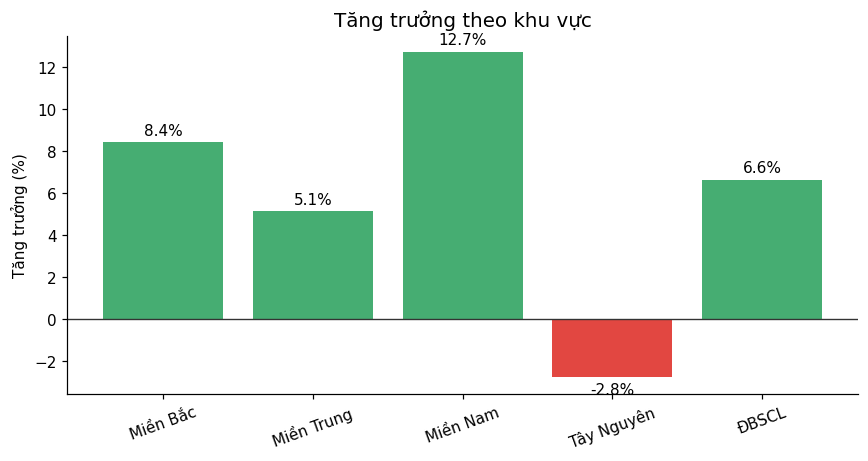

In [10]:
colors = np.where(regions["Tăng trưởng (%)"] >= 0, "#2ca25f", "#de2d26")

fig, ax = plt.subplots(figsize=(8, 4.3))
bars = ax.bar(regions["Khu vực"], regions["Tăng trưởng (%)"], color=colors, alpha=0.88)
ax.axhline(0, color="#333333", linewidth=0.9)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set(title="Tăng trưởng theo khu vực", ylabel="Tăng trưởng (%)", xlabel="")
ax.tick_params(axis="x", rotation=20)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()


### Bài tập 3 — Bar chart

Tạo bar chart **lợi nhuận theo tháng**, tô màu tháng có lợi nhuận cao hơn trung vị bằng xanh đậm.

**Gợi ý:** `median_profit = monthly["Lợi nhuận"].median()` và `np.where(...)`.


In [11]:
# TODO
median_profit = monthly["Lợi nhuận"].median()
# profit_colors = np.where(monthly["Lợi nhuận"] >= median_profit, "#006837", "#b7e4c7")
# fig, ax = plt.subplots(...)
# ax.bar(..., color=profit_colors)

print(f"Trung vị lợi nhuận: {median_profit:,.0f} triệu đồng")


Trung vị lợi nhuận: 898 triệu đồng


## 5. Scatter plot — mối liên hệ giữa hai biến

Mỗi điểm biểu diễn một quan sát. Ngoài vị trí `(x, y)`, ta có thể mã hóa thêm:

- màu qua `c` hoặc `color`;
- kích thước qua `s`;
- độ trong suốt qua `alpha`;
- dạng marker qua `marker`.

> Tương quan quan sát được không tự động chứng minh quan hệ nhân quả.


Hệ số tương quan Pearson: 0.894


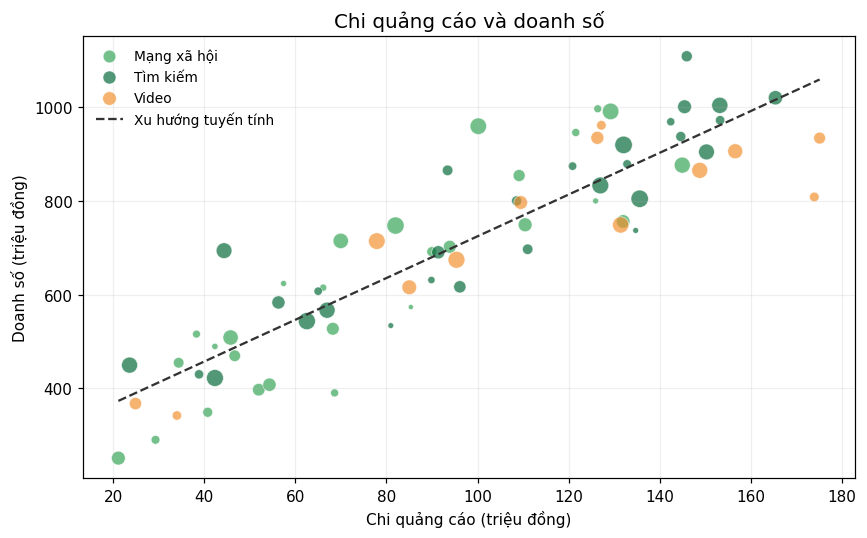

In [12]:
channel_colors = {"Tìm kiếm": "#006837", "Mạng xã hội": "#31a354", "Video": "#f28e2b"}

fig, ax = plt.subplots(figsize=(8, 5))
for channel, group in campaigns.groupby("Kênh"):
    ax.scatter(
        group["Chi quảng cáo"], group["Doanh số"],
        s=group["Số khách"] * 0.22,
        alpha=0.68, edgecolor="white", linewidth=0.5,
        color=channel_colors[channel], label=channel,
    )

# Đường xu hướng tuyến tính mô tả, không phải kết luận nhân quả.
slope, intercept = np.polyfit(campaigns["Chi quảng cáo"], campaigns["Doanh số"], 1)
x_line = np.linspace(campaigns["Chi quảng cáo"].min(), campaigns["Chi quảng cáo"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="#333333", linestyle="--", label="Xu hướng tuyến tính")

ax.set(title="Chi quảng cáo và doanh số", xlabel="Chi quảng cáo (triệu đồng)", ylabel="Doanh số (triệu đồng)")
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()

corr = campaigns[["Chi quảng cáo", "Doanh số"]].corr().iloc[0, 1]
print(f"Hệ số tương quan Pearson: {corr:.3f}")


### Scatter plot với colormap và colorbar

Khi màu đại diện cho một biến số liên tục, dùng colormap và colorbar thay vì legend rời rạc.


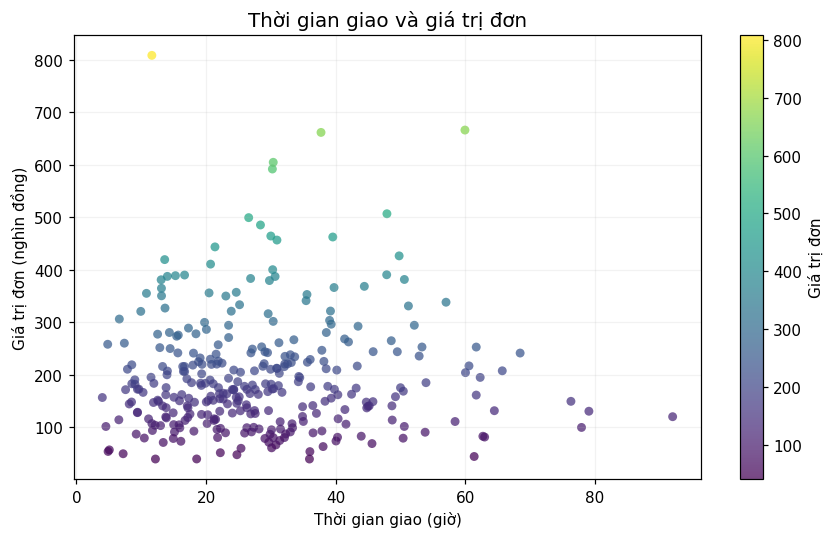

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    delivery["Thời gian giao (giờ)"], delivery["Giá trị đơn"],
    c=delivery["Giá trị đơn"], cmap="viridis",
    s=34, alpha=0.72, edgecolor="none",
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Giá trị đơn")
ax.set(title="Thời gian giao và giá trị đơn", xlabel="Thời gian giao (giờ)", ylabel="Giá trị đơn (nghìn đồng)")
ax.grid(alpha=0.16)
fig.tight_layout()


### Bài tập 4 — Scatter plot

Vẽ số khách trên trục x và doanh số trên trục y. Màu điểm theo kênh, kích thước cố định. Viết một câu nhận xét về xu hướng, độ phân tán và ngoại lệ.


In [14]:
# TODO
# fig, ax = plt.subplots(figsize=(8, 5))
# for channel, group in campaigns.groupby("Kênh"):
#     ax.scatter(group["Số khách"], group["Doanh số"], label=channel, ...)
# ax.legend()

print("Gợi ý đọc hình: nêu chiều xu hướng, độ mạnh và các điểm khác thường.")


Gợi ý đọc hình: nêu chiều xu hướng, độ mạnh và các điểm khác thường.


## 6. Histogram và box plot — khám phá phân phối

Histogram gom quan sát vào các khoảng (`bins`). Hình dạng phụ thuộc số bins, vì vậy nên thử một vài lựa chọn hợp lý. Box plot cô đọng trung vị, tứ phân vị và các điểm ngoại lệ theo quy tắc IQR.


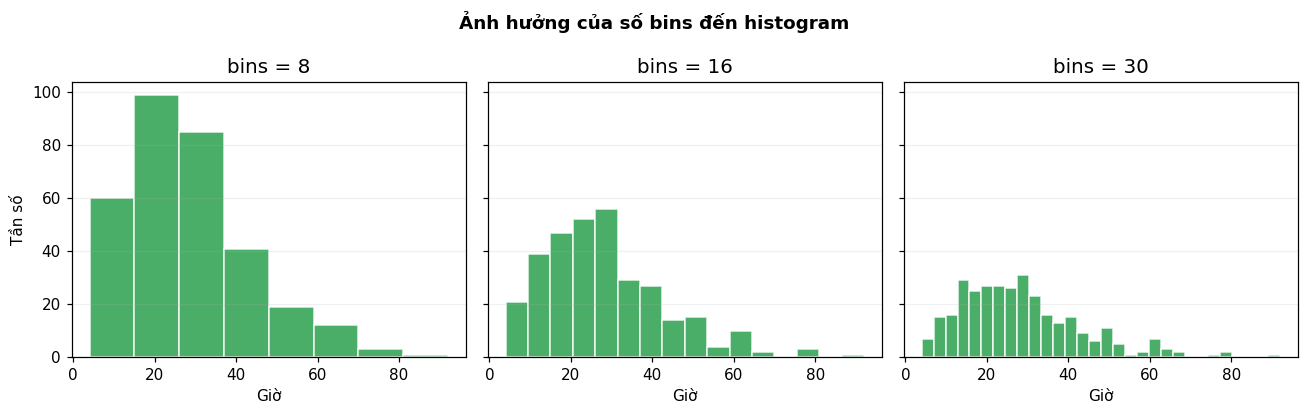

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)

for ax, bins in zip(axes, [8, 16, 30]):
    ax.hist(delivery["Thời gian giao (giờ)"], bins=bins, color="#31a354", edgecolor="white", alpha=0.88)
    ax.set_title(f"bins = {bins}")
    ax.set_xlabel("Giờ")
    ax.grid(axis="y", alpha=0.18)

axes[0].set_ylabel("Tần số")
fig.suptitle("Ảnh hưởng của số bins đến histogram", fontweight="bold")
fig.tight_layout()


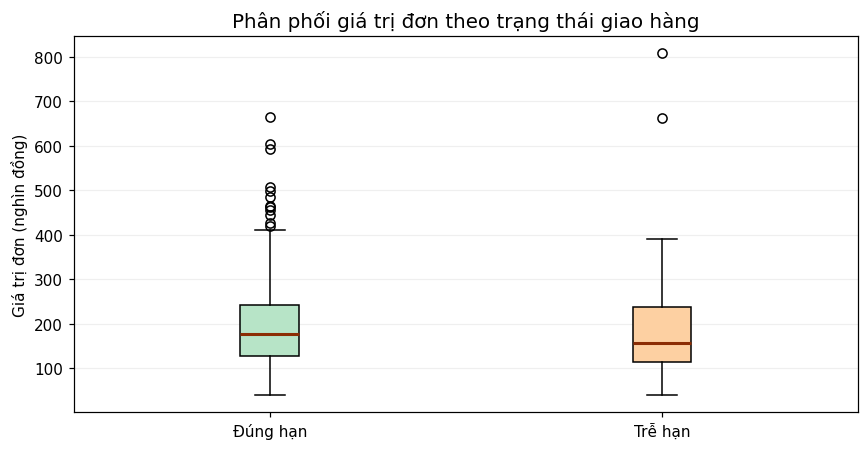

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.2))
groups = [
    delivery.loc[delivery["Đúng hạn"] == status, "Giá trị đơn"]
    for status in ["Có", "Không"]
]
bp = ax.boxplot(
    groups, tick_labels=["Đúng hạn", "Trễ hạn"], patch_artist=True,
    medianprops={"color": "#8c2d04", "linewidth": 2},
)
for patch, color in zip(bp["boxes"], ["#b7e4c7", "#fdd0a2"]):
    patch.set_facecolor(color)

ax.set(title="Phân phối giá trị đơn theo trạng thái giao hàng", ylabel="Giá trị đơn (nghìn đồng)")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()


### Bài tập 5 — Phân phối

1. Vẽ histogram của `Giá trị đơn` với 20 bins.
2. Thêm đường dọc tại trung vị bằng `ax.axvline`.
3. So sánh trung bình và trung vị: phân phối có lệch phải không?


In [17]:
# TODO
order_mean = delivery["Giá trị đơn"].mean()
order_median = delivery["Giá trị đơn"].median()

# fig, ax = plt.subplots(...)
# ax.hist(delivery["Giá trị đơn"], bins=20, ...)
# ax.axvline(order_median, ...)

print(f"Trung bình = {order_mean:.1f}; trung vị = {order_median:.1f}")


Trung bình = 198.5; trung vị = 173.5


## 7. Pie chart — dùng có chọn lọc

Pie chart có thể dùng khi:

- số nhóm ít;
- tổng thể là 100%;
- mục tiêu là nhấn mạnh tỷ trọng lớn.

Nếu cần so sánh chính xác các nhóm gần nhau, bar chart thường dễ đọc hơn.


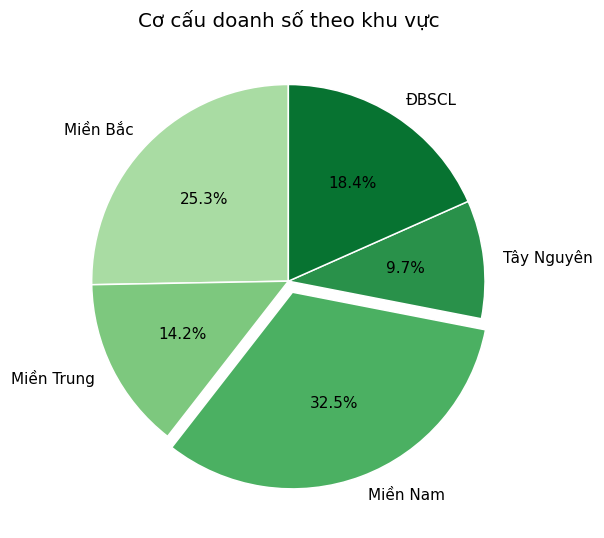

In [18]:
share = regions.set_index("Khu vực")["Doanh số"]
explode = [0.0, 0.0, 0.06, 0.0, 0.0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(
    share,
    labels=share.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=explode,
    colors=plt.cm.Greens(np.linspace(0.35, 0.85, len(share))),
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)
ax.set_title("Cơ cấu doanh số theo khu vực")
fig.tight_layout()


### Bài tập 6 — Chọn đúng dạng biểu đồ

Vẽ lại cơ cấu doanh số bằng bar chart đã sắp xếp giảm dần. So sánh hai hình và trả lời: hình nào giúp xếp hạng khu vực nhanh hơn?


In [19]:
# TODO
share_sorted = share.sort_values(ascending=False)
# fig, ax = plt.subplots(...)
# ax.bar(share_sorted.index, share_sorted.values, ...)

print("Kết luận gợi ý: chiều dài chung một đường chuẩn thường dễ so sánh hơn góc và diện tích.")


Kết luận gợi ý: chiều dài chung một đường chuẩn thường dễ so sánh hơn góc và diện tích.


## 8. Tùy biến giao diện

Matplotlib cho phép kiểm soát gần như mọi thành phần. Tuy nhiên, tùy biến nên phục vụ thông điệp dữ liệu. Một thứ tự làm việc hữu ích:

1. chọn đúng dạng biểu đồ;
2. đặt tiêu đề và nhãn có đơn vị;
3. làm nổi bật dữ liệu quan trọng;
4. giảm thành phần thừa;
5. kiểm tra khả năng đọc khi xuất file.


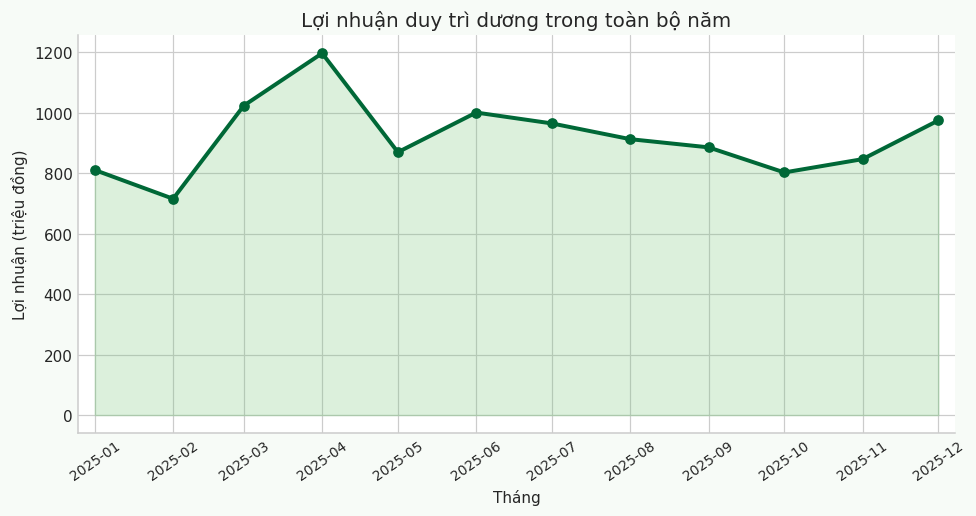

In [20]:
with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax = plt.subplots(figsize=(9, 4.8), facecolor="#f7fbf7")
    ax.set_facecolor("#ffffff")
    ax.plot(monthly["Tháng"], monthly["Lợi nhuận"], color="#006837", linewidth=2.6, marker="o")
    ax.fill_between(monthly["Tháng"], 0, monthly["Lợi nhuận"], color="#74c476", alpha=0.25)
    ax.set(
        title="Lợi nhuận duy trì dương trong toàn bộ năm",
        xlabel="Tháng", ylabel="Lợi nhuận (triệu đồng)",
    )
    ax.tick_params(axis="x", labelrotation=35, labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.02)
    fig.tight_layout()


### `rcParams` và context

- `plt.rcParams.update(...)`: thay đổi mặc định cho phiên làm việc.
- `plt.style.use(...)`: áp dụng style toàn cục.
- `with plt.style.context(...):`: chỉ áp dụng trong một khối mã, an toàn cho notebook dài.
- `plt.rcdefaults()`: quay về mặc định Matplotlib.


In [21]:
available = plt.style.available
print("Một số style có sẵn:", ", ".join(available[:12]))
print("Tổng số style:", len(available))


Một số style có sẵn: Solarize_Light2, _classic_test_patch, _mpl-gallery, _mpl-gallery-nogrid, bmh, classic, dark_background, fast, fivethirtyeight, ggplot, grayscale, petroff10
Tổng số style: 29


## 9. Subplots — nhiều góc nhìn trong một Figure

`plt.subplots(nrows, ncols)` trả về Figure và một hoặc nhiều Axes. Với lưới 2×2, `axes` là mảng hai chiều và truy cập bằng `axes[row, col]`.


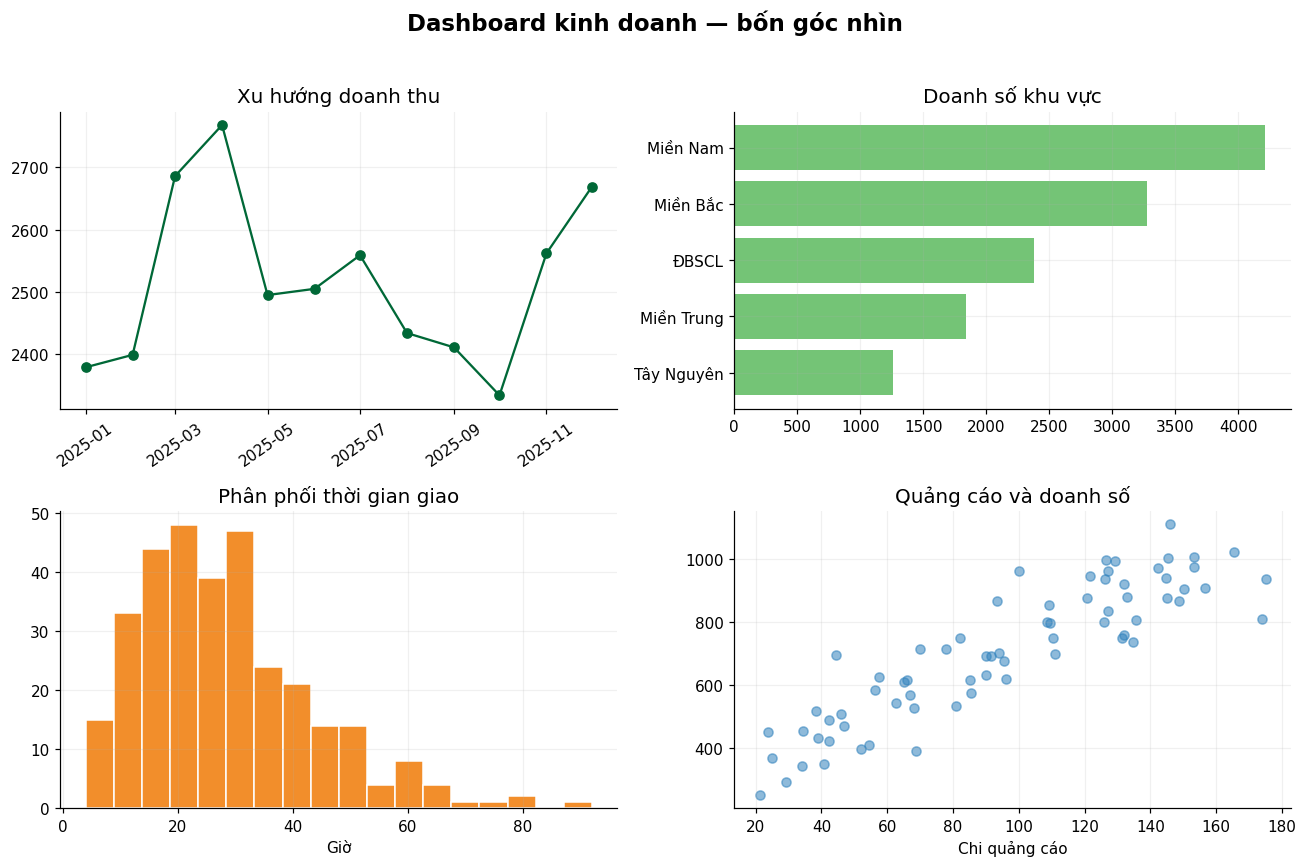

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Xu hướng doanh thu
axes[0, 0].plot(monthly["Tháng"], monthly["Doanh thu"], marker="o", color="#006837")
axes[0, 0].set_title("Xu hướng doanh thu")
axes[0, 0].tick_params(axis="x", rotation=35)

# 2. Doanh số khu vực
axes[0, 1].barh(regions_sorted["Khu vực"], regions_sorted["Doanh số"], color="#74c476")
axes[0, 1].set_title("Doanh số khu vực")

# 3. Phân phối giao hàng
axes[1, 0].hist(delivery["Thời gian giao (giờ)"], bins=18, color="#f28e2b", edgecolor="white")
axes[1, 0].set_title("Phân phối thời gian giao")
axes[1, 0].set_xlabel("Giờ")

# 4. Quảng cáo và doanh số
axes[1, 1].scatter(campaigns["Chi quảng cáo"], campaigns["Doanh số"], alpha=0.55, color="#3182bd")
axes[1, 1].set_title("Quảng cáo và doanh số")
axes[1, 1].set_xlabel("Chi quảng cáo")

for ax in axes.flat:
    ax.grid(alpha=0.18)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Dashboard kinh doanh — bốn góc nhìn", fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])


### Bài tập 7 — Dashboard 1×3

Tạo một Figure gồm ba Axes trên một hàng:

1. lợi nhuận theo tháng;
2. tăng trưởng theo khu vực;
3. histogram giá trị đơn.

**Gợi ý:** `fig, axes = plt.subplots(1, 3, figsize=(15, 4))`.


In [23]:
# TODO
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# axes[0].plot(...)
# axes[1].bar(...)
# axes[2].hist(...)
# fig.suptitle("Dashboard thực hành")
# fig.tight_layout()

print("Bài tập 7: giữ cùng bảng màu và cỡ chữ để dashboard nhất quán.")


Bài tập 7: giữ cùng bảng màu và cỡ chữ để dashboard nhất quán.


## 10. Heatmap tương quan bằng Matplotlib

`imshow` biểu diễn ma trận dưới dạng ảnh. Cần thêm colorbar, nhãn hàng/cột và chú thích giá trị để heatmap tự giải thích.


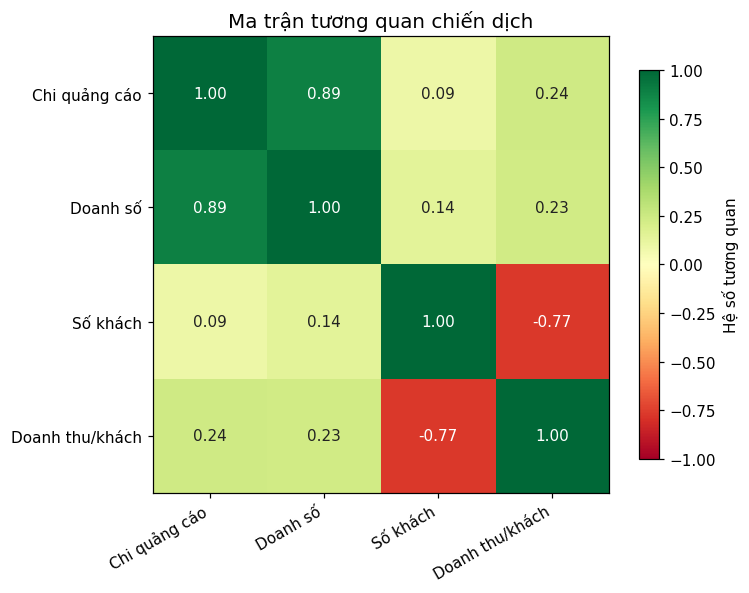

In [24]:
analysis_df = campaigns[["Chi quảng cáo", "Doanh số", "Số khách"]].copy()
analysis_df["Doanh thu/khách"] = analysis_df["Doanh số"] / analysis_df["Số khách"]
corr_matrix = analysis_df.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, shrink=0.85, label="Hệ số tương quan")

ax.set_xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=30, ha="right")
ax.set_yticks(range(len(corr_matrix.index)), corr_matrix.index)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        value = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                color="white" if abs(value) > 0.55 else "#222222")

ax.set_title("Ma trận tương quan chiến dịch")
fig.tight_layout()


## 11. Contour và đồ thị 3D

Ta mô phỏng một bề mặt hiệu quả bán hàng theo hai biến:

- `x`: ngân sách quảng cáo;
- `y`: mức giảm giá;
- `z`: chỉ số hiệu quả dự đoán.

Contour thể hiện các đường đồng mức; surface 3D thể hiện cùng dữ liệu dưới dạng bề mặt.


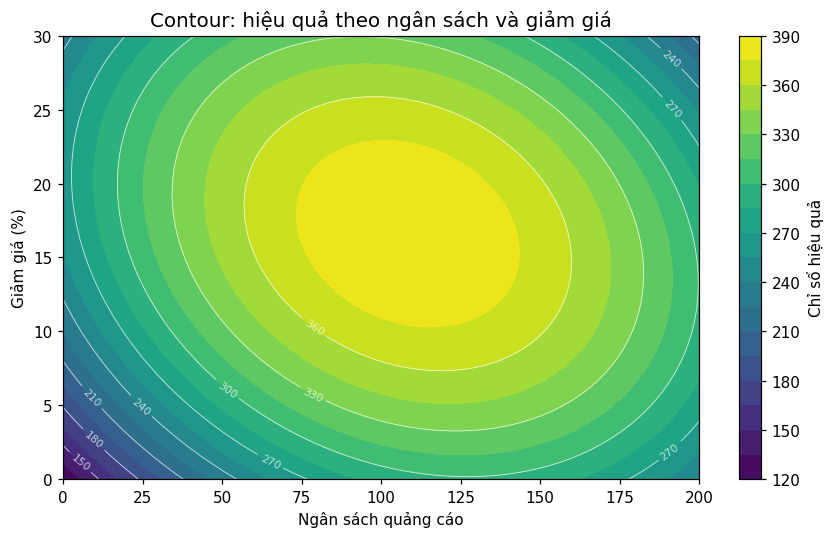

In [25]:
x_budget = np.linspace(0, 200, 90)
y_discount = np.linspace(0, 30, 80)
X, Y = np.meshgrid(x_budget, y_discount)
Z = 120 + 2.8 * X + 14 * Y - 0.011 * X**2 - 0.34 * Y**2 - 0.025 * X * Y

fig, ax = plt.subplots(figsize=(8, 5))
contour = ax.contourf(X, Y, Z, levels=18, cmap="viridis")
lines = ax.contour(X, Y, Z, levels=8, colors="white", linewidths=0.6, alpha=0.7)
ax.clabel(lines, inline=True, fontsize=7, fmt="%.0f")
fig.colorbar(contour, ax=ax, label="Chỉ số hiệu quả")
ax.set(title="Contour: hiệu quả theo ngân sách và giảm giá",
       xlabel="Ngân sách quảng cáo", ylabel="Giảm giá (%)")
fig.tight_layout()


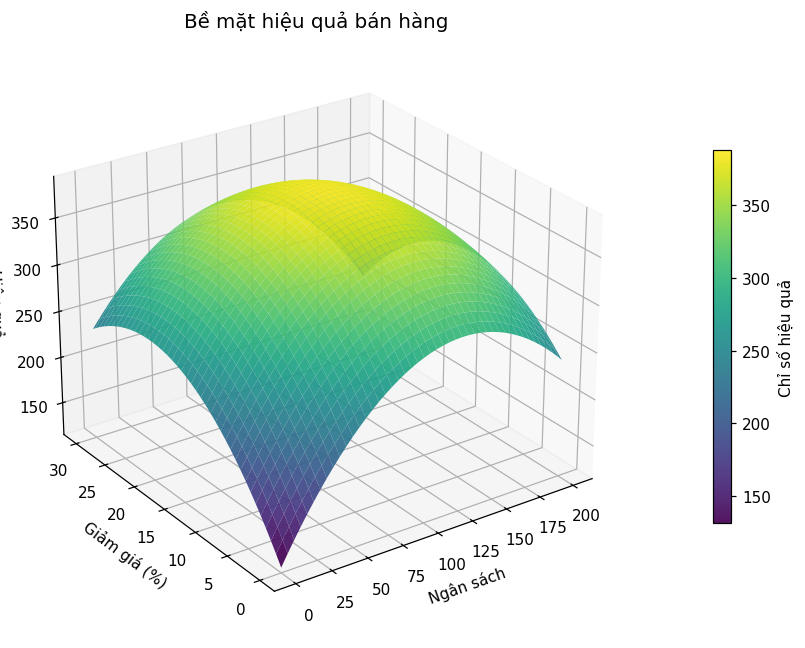

In [26]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0, antialiased=True, alpha=0.92)
fig.colorbar(surface, ax=ax, shrink=0.62, pad=0.10, label="Chỉ số hiệu quả")
ax.set(title="Bề mặt hiệu quả bán hàng",
       xlabel="Ngân sách", ylabel="Giảm giá (%)", zlabel="Hiệu quả")
ax.view_init(elev=26, azim=-125)
fig.tight_layout()


### Bài tập 8 — Đọc contour

Quan sát vùng có chỉ số hiệu quả lớn nhất. Trả lời:

1. Tăng ngân sách luôn làm hiệu quả tăng không?
2. Giảm giá quá cao có thể ảnh hưởng thế nào?
3. Vì sao contour đôi khi dễ đọc chính xác hơn surface 3D?


In [27]:
max_pos = np.unravel_index(np.argmax(Z), Z.shape)
print(f"Điểm cực đại trên lưới: ngân sách ≈ {X[max_pos]:.1f}, giảm giá ≈ {Y[max_pos]:.1f}, hiệu quả ≈ {Z[max_pos]:.1f}")


Điểm cực đại trên lưới: ngân sách ≈ 107.9, giảm giá ≈ 16.7, hiệu quả ≈ 388.0


## 12. Matplotlib với Pandas

Pandas cung cấp phương thức `.plot()` nhưng vẫn trả về một Matplotlib `Axes`. Vì vậy, ta có thể tạo biểu đồ nhanh bằng Pandas rồi tiếp tục tùy biến bằng API của Matplotlib.


Đối tượng trả về: Axes


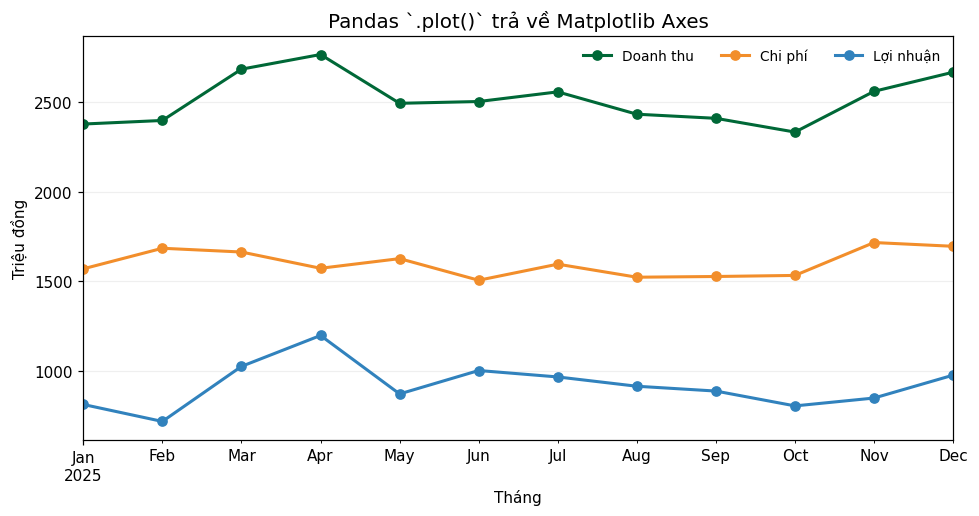

In [28]:
monthly_plot = monthly.set_index("Tháng")[["Doanh thu", "Chi phí", "Lợi nhuận"]]

ax = monthly_plot.plot(
    figsize=(9, 4.8), marker="o", linewidth=2,
    color=["#006837", "#f28e2b", "#3182bd"],
)
ax.set(title="Pandas `.plot()` trả về Matplotlib Axes", xlabel="Tháng", ylabel="Triệu đồng")
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, ncols=3)
ax.figure.tight_layout()

print("Đối tượng trả về:", type(ax).__name__)


## 13. Matplotlib với Seaborn

Seaborn tạo lớp giao diện thống kê mức cao hơn nhưng vẫn dùng Figure/Axes của Matplotlib. Nếu môi trường chưa cài Seaborn, ô dưới sẽ in hướng dẫn thay vì làm notebook dừng lỗi.


Seaborn: 0.13.2


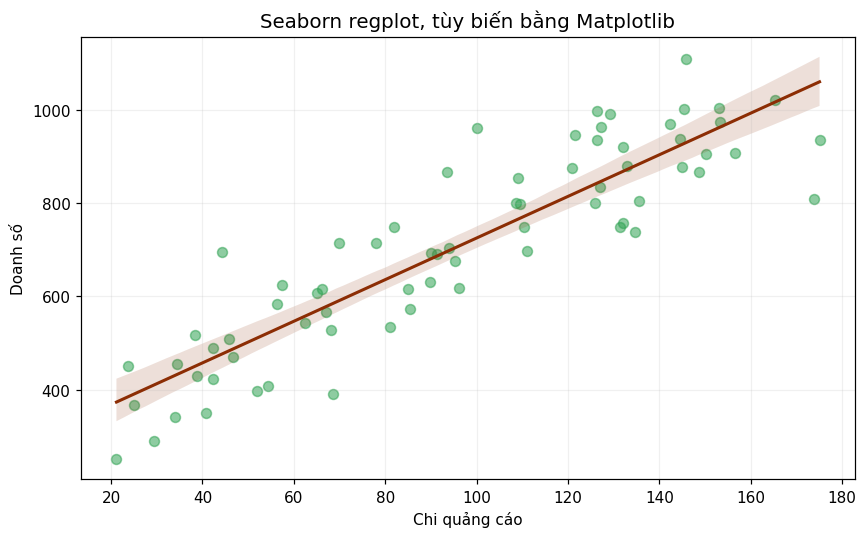

In [29]:
try:
    import seaborn as sns

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.regplot(
        data=campaigns, x="Chi quảng cáo", y="Doanh số", ax=ax,
        scatter_kws={"alpha": 0.55, "s": 42, "color": "#31a354"},
        line_kws={"color": "#8c2d04", "linewidth": 2},
    )
    ax.set_title("Seaborn regplot, tùy biến bằng Matplotlib")
    ax.grid(alpha=0.18)
    fig.tight_layout()
    print("Seaborn:", sns.__version__)
except ImportError:
    print("Chưa có Seaborn. Cài bằng: pip install seaborn")


## 14. Widget tương tác

`matplotlib.widgets` hỗ trợ slider, button, checkbox... Mức độ tương tác phụ thuộc backend. Trong JupyterLab, có thể cần `ipympl` và lệnh `%matplotlib widget`.

Ví dụ sau tạo slider điều khiển tần số sóng. Kết quả nhúng trong tài liệu là trạng thái ban đầu; khi dùng backend tương tác, kéo slider sẽ cập nhật đường.


Slider đã được tạo. Dùng backend tương tác để kéo trực tiếp.


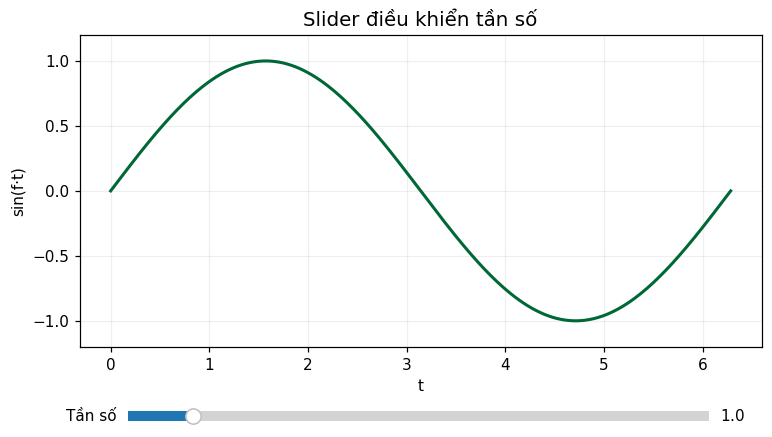

In [30]:
from matplotlib.widgets import Slider

t = np.linspace(0, 2 * np.pi, 300)
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.subplots_adjust(bottom=0.25)

frequency0 = 1.0
wave_line, = ax.plot(t, np.sin(frequency0 * t), color="#006837", linewidth=2)
ax.set(title="Slider điều khiển tần số", xlabel="t", ylabel="sin(f·t)", ylim=(-1.2, 1.2))
ax.grid(alpha=0.2)

slider_ax = fig.add_axes([0.18, 0.09, 0.66, 0.04])
frequency_slider = Slider(slider_ax, "Tần số", 0.5, 5.0, valinit=frequency0, valstep=0.1)

def update_frequency(value):
    wave_line.set_ydata(np.sin(value * t))
    fig.canvas.draw_idle()

frequency_slider.on_changed(update_frequency)
print("Slider đã được tạo. Dùng backend tương tác để kéo trực tiếp.")


## 15. Xuất biểu đồ

Lệnh chính là `fig.savefig(...)`.

- PNG: phù hợp web, email, tài liệu thông thường;
- SVG: vector, tốt cho chỉnh sửa và web;
- PDF: vector, phù hợp báo cáo/in ấn;
- `bbox_inches="tight"`: giảm khoảng trắng thừa;
- `transparent=True`: nền trong suốt khi cần ghép thiết kế.


Đã tạo: matplotlib_outputs_v1/doanh_thu.png — 66,483 bytes
Đã tạo: matplotlib_outputs_v1/doanh_thu.pdf — 12,968 bytes
Đã tạo: matplotlib_outputs_v1/doanh_thu.svg — 28,060 bytes


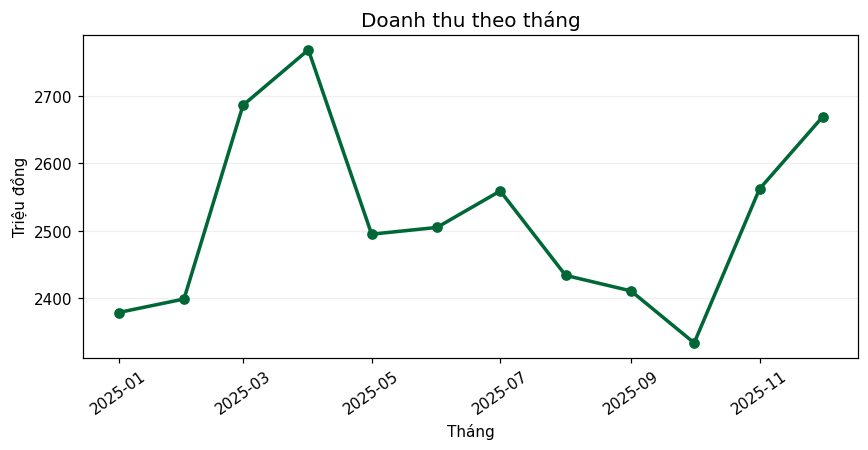

In [31]:
export_dir = Path("matplotlib_outputs_v1")
export_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(monthly["Tháng"], monthly["Doanh thu"], marker="o", color="#006837", linewidth=2.3)
ax.set(title="Doanh thu theo tháng", xlabel="Tháng", ylabel="Triệu đồng")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()

paths = [
    export_dir / "doanh_thu.png",
    export_dir / "doanh_thu.pdf",
    export_dir / "doanh_thu.svg",
]
for path in paths:
    fig.savefig(path, bbox_inches="tight")

for path in paths:
    print(f"Đã tạo: {path} — {path.stat().st_size:,} bytes")


## 16. Viết hàm vẽ tái sử dụng

Một hàm tốt nên nhận `ax` từ bên ngoài và trả lại đối tượng cần thiết. Cách này giúp hàm hoạt động được cả trên một biểu đồ riêng lẻ lẫn trong dashboard nhiều subplot.


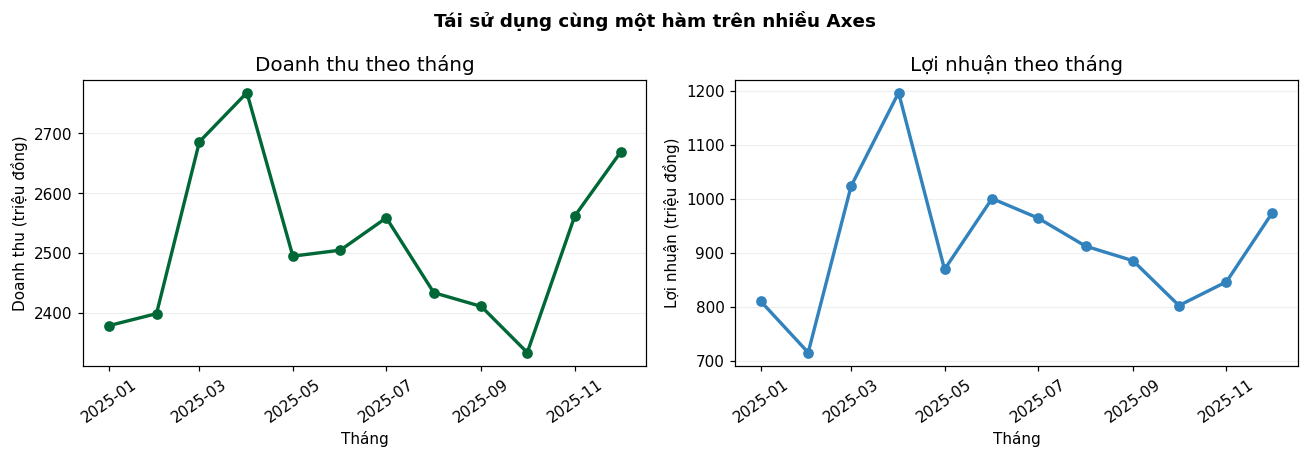

In [32]:
def plot_monthly_metric(data, metric, *, ax=None, color="#006837", title=None):
    # Vẽ một chỉ tiêu theo tháng và trả về Axes để tiếp tục tùy biến.
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))

    ax.plot(data["Tháng"], data[metric], marker="o", color=color, linewidth=2.2)
    ax.set(
        title=title or f"{metric} theo tháng",
        xlabel="Tháng",
        ylabel=f"{metric} (triệu đồng)",
    )
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.2)
    return ax


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
plot_monthly_metric(monthly, "Doanh thu", ax=axes[0], color="#006837")
plot_monthly_metric(monthly, "Lợi nhuận", ax=axes[1], color="#3182bd")
fig.suptitle("Tái sử dụng cùng một hàm trên nhiều Axes", fontweight="bold")
fig.tight_layout()


### Bài tập 9 — Mở rộng hàm

Thêm các tham số:

- `show_average=True`: bật/tắt đường trung bình;
- `marker="o"`: cho phép đổi marker;
- `unit="triệu đồng"`: thay đổi đơn vị trục y.

Sau đó thử hàm với cột `Chi phí`.


In [33]:
# TODO: sao chép hàm ở trên, đổi tên thành plot_monthly_metric_v2 và bổ sung tham số.
# def plot_monthly_metric_v2(...):
#     ...

print("Mẹo: giữ các tham số tùy chọn sau dấu * để lời gọi hàm dễ đọc.")


Mẹo: giữ các tham số tùy chọn sau dấu * để lời gọi hàm dễ đọc.


## 17. Bài thực hành có lời giải — báo cáo điều hành

### Yêu cầu

Tạo dashboard 2×2 gồm:

1. doanh thu và chi phí theo tháng;
2. lợi nhuận theo tháng, nhấn mạnh tháng tốt nhất;
3. doanh số theo khu vực, sắp xếp tăng dần;
4. chi quảng cáo và doanh số, kèm đường xu hướng.

Tiêu chí:

- tiêu đề và nhãn trục có đơn vị;
- màu nhất quán;
- lưới nhẹ, bỏ khung trên/phải;
- có `suptitle` cho toàn Figure;
- lưu kết quả thành PNG.


Đã lưu: matplotlib_outputs_v1/dashboard_dieu_hanh.png (260,535 bytes)


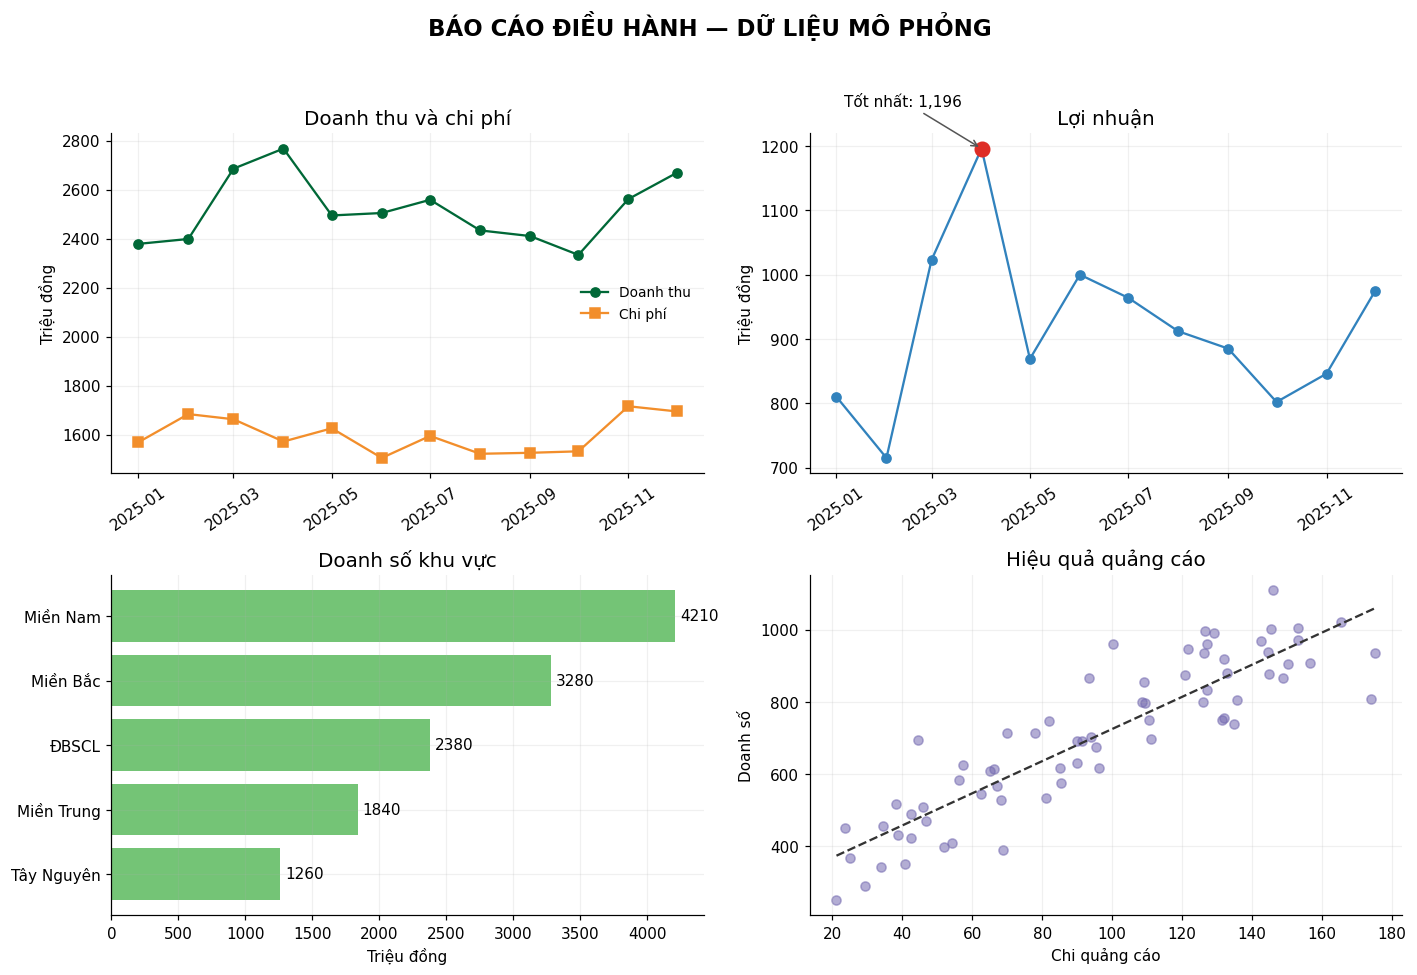

In [34]:
# LỜI GIẢI THAM KHẢO
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Doanh thu và chi phí
ax = axes[0, 0]
ax.plot(monthly["Tháng"], monthly["Doanh thu"], marker="o", color="#006837", label="Doanh thu")
ax.plot(monthly["Tháng"], monthly["Chi phí"], marker="s", color="#f28e2b", label="Chi phí")
ax.set(title="Doanh thu và chi phí", ylabel="Triệu đồng")
ax.legend(frameon=False)
ax.tick_params(axis="x", rotation=35)

# (2) Lợi nhuận
ax = axes[0, 1]
ax.plot(monthly["Tháng"], monthly["Lợi nhuận"], marker="o", color="#3182bd")
best = monthly.loc[monthly["Lợi nhuận"].idxmax()]
ax.scatter(best["Tháng"], best["Lợi nhuận"], s=90, color="#de2d26", zorder=3)
ax.annotate(f"Tốt nhất: {best['Lợi nhuận']:,.0f}", xy=(best["Tháng"], best["Lợi nhuận"]),
            xytext=(-90, 28), textcoords="offset points",
            arrowprops={"arrowstyle": "->", "color": "#555555"})
ax.set(title="Lợi nhuận", ylabel="Triệu đồng")
ax.tick_params(axis="x", rotation=35)

# (3) Khu vực
ax = axes[1, 0]
bars = ax.barh(regions_sorted["Khu vực"], regions_sorted["Doanh số"], color="#74c476")
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set(title="Doanh số khu vực", xlabel="Triệu đồng")

# (4) Chi quảng cáo và doanh số
ax = axes[1, 1]
ax.scatter(campaigns["Chi quảng cáo"], campaigns["Doanh số"], alpha=0.55, color="#756bb1")
ax.plot(x_line, slope * x_line + intercept, linestyle="--", color="#333333")
ax.set(title="Hiệu quả quảng cáo", xlabel="Chi quảng cáo", ylabel="Doanh số")

for ax in axes.flat:
    ax.grid(alpha=0.18)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("BÁO CÁO ĐIỀU HÀNH — DỮ LIỆU MÔ PHỎNG", fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])

dashboard_path = export_dir / "dashboard_dieu_hanh.png"
fig.savefig(dashboard_path, bbox_inches="tight", dpi=180)
print("Đã lưu:", dashboard_path, f"({dashboard_path.stat().st_size:,} bytes)")


## 18. Bài tập tổng hợp tự làm

### Tình huống

Bạn là chuyên viên phân tích cần gửi một Figure cho quản lý. Hãy tạo một dashboard mới từ các bảng trong notebook.

### Yêu cầu bắt buộc

1. Có ít nhất ba dạng biểu đồ khác nhau.
2. Có một annotation chỉ ra điểm đáng chú ý.
3. Có một biến được mã hóa bằng màu hoặc kích thước.
4. Tiêu đề phải truyền đạt thông điệp, không chỉ ghi tên biến.
5. Xuất file PNG với `dpi>=150`.

### Câu hỏi tự đánh giá

- Người xem nhận ra thông điệp chính trong 5 giây không?
- Trục có đơn vị và phạm vi hợp lý không?
- Màu có nhất quán và phân biệt được không?
- Có thành phần trang trí nào không phục vụ thông tin không?
- Biểu đồ có thể gây hiểu sai quan hệ nhân quả không?


In [35]:
# TODO — khu vực làm bài tổng hợp.
# fig, axes = plt.subplots(...)
# ...
# fig.savefig(export_dir / "bai_tong_hop_cua_toi.png", dpi=180, bbox_inches="tight")

print("Hãy xây dựng dashboard của bạn tại ô này.")


Hãy xây dựng dashboard của bạn tại ô này.


## 19. Cheat sheet lệnh Matplotlib

| Mục tiêu | Lệnh chính |
|---|---|
| Tạo Figure/Axes | `fig, ax = plt.subplots(figsize=(8, 4))` |
| Line chart | `ax.plot(x, y, marker="o")` |
| Bar chart | `ax.bar(categories, values)` |
| Bar ngang | `ax.barh(categories, values)` |
| Scatter | `ax.scatter(x, y, c=color, s=size, alpha=.6)` |
| Histogram | `ax.hist(values, bins=20)` |
| Box plot | `ax.boxplot(groups)` |
| Pie chart | `ax.pie(values, labels=labels, autopct="%1.1f%%")` |
| Tiêu đề/nhãn | `ax.set(title=..., xlabel=..., ylabel=...)` |
| Legend | `ax.legend()` |
| Grid | `ax.grid(alpha=.2)` |
| Đường tham chiếu | `ax.axhline(...)`, `ax.axvline(...)` |
| Chú thích | `ax.annotate(text, xy=..., xytext=...)` |
| Colorbar | `fig.colorbar(mappable, ax=ax)` |
| Subplots | `fig, axes = plt.subplots(2, 2)` |
| Bố cục | `fig.tight_layout()` |
| Xuất file | `fig.savefig("chart.png", dpi=180, bbox_inches="tight")` |

### Checklist trước khi nộp biểu đồ

- [ ] Đúng loại biểu đồ cho câu hỏi?
- [ ] Tiêu đề nêu rõ thông điệp?
- [ ] Nhãn trục có đơn vị?
- [ ] Màu và legend nhất quán?
- [ ] Không cắt trục gây hiểu sai?
- [ ] Đọc được khi chiếu hoặc in?
- [ ] Đã lưu đúng định dạng và độ phân giải?


## Kết thúc

Bạn đã đi qua quy trình đầy đủ: **chuẩn bị dữ liệu → chọn biểu đồ → tùy biến → ghép dashboard → xuất file**.

Bước tiếp theo nên làm là thay dữ liệu mô phỏng bằng một DataFrame thực tế của bạn và tái sử dụng các hàm/khung biểu đồ trong notebook này.
